In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR01b — Resurslar–istifadə balansı: ÜDM-in xərc metodu və məcmu tələb–təklif tarazlığı

ÜDM-in **istifadə (xərc) hesabının** qurulması və mal-xidmət bazarının tarazlıq şərtinin
hər il üçün eyniliklə bağlanması:

$$\underbrace{Y + M}_{\text{məcmu resurslar (təklif)}} \;\equiv\;
\underbrace{C^{ev} + C^{QHT} + C^{döv} + I^{əsas} + \Delta S + X}_{\text{məcmu istifadə (tələb)}}$$

Dəftər MİİS §15.5.1-in ayrıca nömrələnmiş tələbi deyil — o, **icmalın qeydinə** cavabdır:
«Sistemdə makroiqtisadi tarazlığın (tələb-təklif balansının) necə təmin olunduğunu müəyyən etmək
mümkün olmadı. Əgər modeldə yoxdursa, bu tarazlığın təmin olunması vacibdir; modeldə tələb və
təklif tarazlığı görünmür.» Ona görə nömrələnmə FR05b-nin konvensiyası ilədir: FR01-in bloku,
ayrıca dəftər.

## 1. Tələb və bu dəftərin cavabı

**İcmalın qeydi.** Paketin əvvəlki buraxılışında iqtisadiyyatın **təklif tərəfi** tam qurulmuşdu —
on bir sahənin əlavə dəyəri, məhsula və idxala xalis vergilər, neft-qaz bloku (FR02, FR03, FR05b) —
və **tələbin bəzi elementləri** davranış tənlikləri ilə modelləşdirilirdi (FR01-in simultan
nüvəsində investisiya və son istehlak, FR07-də absorbsiyadan asılı idxal). Lakin bu iki tərəf
heç bir yerdə **bir cədvəldə** qarşı-qarşıya qoyulmurdu: nə xərc metodu ilə ÜDM hesabı vardı,
nə də «resurslar = istifadə» eyniliyi. FR01-in 7.6 bölməsi sualın yalnız yarısını bağlayırdı —
qeyri-neft ÜDM-in iki oxunuşunun fərqini nəşr edirdi — və açıq şəkildə yazırdı ki, tam xərc
hesabı sonrakı mərhələnin işidir.

**Bu dəftər həmin mərhələdir və üç iş görür.**

1. **Balansı görünən edir.** ÜDM-in istifadə hesabı 2013–2030 üçün altı komponentlə (ev
   təsərrüfatlarının, QHT-lərin və dövlətin son istehlakı, əsas kapitalın ümumi yığımı,
   ehtiyatların dəyişməsi, ixrac və idxal) qurulur; hər il üçün resurslar və istifadə cədvəldə
   yan-yana verilir.
2. **Balansı təmin edir.** Tarazlıq **eyniliklə** bağlanır: hesabın bir maddəsi qapayıcı
   (balanslaşdırıcı) maddə kimi təyin edilir və qalıq ona verilir. Hansı maddənin qapayıcı
   olacağı fikirlə deyil, **açıq testlə** seçilir (Bölmə 4): namizədlərin hər biri üçün implisit
   pay hesablanır və onun 2013–2025 müşahidə aralığından kənara çıxıb-çıxmadığı yoxlanılır.
   Testi yalnız bir namizəd keçir.
3. **Uyğunsuzluğu gizlətmir.** Davranış bloklarından gələn tələb ilə təklif arasındakı fərq
   `use_balance_gap` sırası kimi nəşr olunur (faktiki illərdə DSK-nın öz statistik fərqi, proqnoz
   illərində modelin öz fərqi) və qapayıcı maddənin davranış yolundan uzaqlaşması ayrıca sıra ilə
   verilir. Səssiz balanslaşdırma paketin qadağan etdiyi yeganə düzəliş növüdür (D4) — burada da
   tətbiq edilmir: qapanış AÇIQ elan olunan qayda ilə aparılır və ölçüsü çap edilir.

**Nə DATA-GAP idi, nə də deyil.** FR01-in əvvəlki mətni xərc hesabının qurulmasına iki maneə
göstərirdi: dövlətin son istehlakı və **ehtiyatların dəyişməsi** «heç bir mənbədə yoxdur».
Birinci maneə əvvəlki buraxılışda bağlanmışdı (DSK 27, P.3 + P.4). İkincisi isə **səhv qeyd
idi**: DSK-nın 27-ci cədvəli «Gross domestic product use, at current prices» adlanır və
ehtiyatların dəyişməsini (P.52) 1993-cü ildən verir — sadəcə məlumat qatı həmin cədvəldən yalnız
üç sətir oxuyurdu. Bu buraxılışda oxucu cədvəlin **hamısını** oxuyur (bax `data_layer` §14,
`_read_ssc027`) və qeyd ləğv edilib.

**İcra sırasında yeri.** Dəftər FR07-dən (xarici ticarət) SONRA gəlir, çünki ixrac və idxalın
manatla yolu FR07-nin dollarla axınlarından və FR10-un orta illik məzənnəsindən qurulur; FR11 və
FR12-dən ƏVVƏL gəlir və onların heç bir sırasına toxunmur. Yeni DAG: … → FR07 → **FR01b** →
FR11 → FR12 → FR13.

## 2. Məlumat

Dəftər **yeni müşahidə gətirmir**: bütün faktiki sıralar məlumat qatından, bütün proqnoz girişləri
isə yuxarı axın dəftərlərinin artıq nəşr etdiyi `outputs/forecast_long.csv` sətirlərindən oxunur.

**Faktiki hissə — DSK 27 «Gross domestic product use, at current prices» (1993–2025).**

| `series_code` | SNA | Göstərici | Sətir |
|---|---|---|---|
| `cons_final_total` | P.4 | Faktiki son istehlak xərcləri, cəmi | 5 |
| `hh_cons_actual` | P.4 | Ev təsərrüfatlarının **faktiki** son istehlakı | 7 |
| `hh_cons_final` | P.3 | Ev təsərrüfatlarının **öz** son istehlak xərcləri | 9 |
| `gov_cons_indiv` | P.3 | Dövlətin fərdi xidmət xərcləri | 10 |
| `npish_cons_final` | P.3 | QHT-lərin son istehlak xərcləri | 11 |
| `gov_cons_collect` | P.4 | Dövlətin kollektiv xidmət xərcləri | 12 |
| `gcf_total` | P.5 | Ümumi yığım | 13 |
| `gfcf_total` | P.51 | Əsas kapitalın ümumi yığımı | 14 |
| `inventories_chg` | P.52 | Ehtiyatların dəyişməsi | 15 |
| `net_exports_gs` | P.6n | Xalis ixrac | 16 |
| `exports_gs` | P.6 | Mal və xidmətlərin ixracı | 17 |
| `imports_gs` | P.7 | Mal və xidmətlərin idxalı | 18 |
| `stat_discrepancy` | — | Statistik fərq | 19 |
| `gdp_use` | B.1*g | ÜDM, istifadə hesabı üzrə | 20 |

**Proqnoz girişləri — paketin öz blokları.**

| Giriş | Mənbə | Rolu |
|---|---|---|
| `gdp_prod` | FR02 (istehsal metodu) | təklif tərəfi — baş göstərici |
| `g_cons_core` | FR01 nüvəsi (`assumptions.csv`) | ev təsərrüfatı istehlakının real artımı |
| `cpi_infl` | FR09 (`assumptions.csv`) | istehlak deflyatoru |
| `gov_cons_total` | FR01 (fiskal ötürücü) | dövlətin son istehlakı, səviyyə |
| `inv_total_nom` | FR06 | investisiya yolu — yığımın davranış oxunuşu |
| `exp_goods`, `exp_services`, `imp_goods`, `imp_services` | FR07 | ticarət axınları, mln USD |
| `fx_usd_azn_avg` | FR10 | orta illik məzənnə, USD → AZN |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True, "grid.alpha": 0.30,
                     "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110})

LA, FY = config.LAST_ACTUAL, list(config.FY)
FR = "FR1B"
WB = "DSK 27 (027en)"
SH = "027 — Gross domestic product use"
HW = list(range(2013, LA + 1))            # tarixi pəncərə: paketin qalan hissəsi ilə eyni

USE_CODES = ["cons_final_total", "hh_cons_actual", "hh_cons_final", "gov_cons_indiv",
             "npish_cons_final", "gov_cons_collect", "gov_cons_total", "gcf_total",
             "gfcf_total", "inventories_chg", "net_exports_gs", "exports_gs", "imports_gs",
             "stat_discrepancy", "gdp_use"]
U = pd.DataFrame({c: data_layer.actuals(c) for c in USE_CODES})
print(f"DSK 27 istifadə hesabı: {int(U.index.min())}–{int(U.index.max())}, "
      f"{U.shape[1]} sıra, hər sıra üçün {int(U.notna().sum().min())} müşahidə")
display(U.loc[HW, ["cons_final_total", "gcf_total", "gfcf_total", "inventories_chg",
                   "exports_gs", "imports_gs", "stat_discrepancy", "gdp_use"]].round(1))

DSK 27 istifadə hesabı: 1993–2025, 15 sıra, hər sıra üçün 33 müşahidə


,cons_final_total,gcf_total,gfcf_total,inventories_chg,exports_gs,imports_gs,stat_discrepancy,gdp_use
year,,,,,,,,
2013,30363.0,14928.3,15007.4,-79.1,28169.3,15278.6,0.0,58182.0
2014,33238.8,16234.8,16187.8,47.0,25537.5,15467.4,-529.6,59014.1
2015,37575.7,15179.4,15131.4,48.0,20552.8,18927.9,0.0,54380.0
2016,43228.5,15518.1,15127.3,390.8,28054.0,26375.4,0.0,60425.2
2017,48482.2,17147.6,16752.5,395.1,34147.5,29439.5,0.0,70337.8
2018,51745.1,16122.1,16574.3,-452.2,43323.6,30098.8,-1000.0,80092.0
2019,56205.5,16631.3,17304.3,-673.0,40170.6,30111.2,-1000.0,81896.2
2020,55961.2,17176.3,16450.9,725.4,25854.9,26414.3,0.0,72578.1
2021,61729.2,15917.8,15124.2,793.6,43329.0,27772.8,0.0,93203.2


### 2.1. Mənbənin öz eyniliyi

İstifadə hesabının balansı **mənbənin özündə** yoxlanılır: cədvəlin sətirləri hər il üçün

$$\text{B.1*g} \;=\; \text{P.4} + \text{P.5} + (\text{P.6} - \text{P.7}) + \text{statistik fərq}$$

verməlidir. Bu, oxunuşun sınağıdır: sətir xəritəsi mənbənin yeni buraxılışında sürüşərsə,
eynilik bağlanmır və məlumat qatı istisna atır (`data_layer._read_ssc027`, dözüm 0,15 mln AZN).
Aşağıda eynilik dəftərin özündə də — məlumat qatından **müstəqil** — yenidən hesablanır.

In [3]:
src_resid = (U["gdp_use"]
             - (U["cons_final_total"] + U["gcf_total"] + U["exports_gs"] - U["imports_gs"]
                + U["stat_discrepancy"])).dropna()
print(f"DSK 27-nin öz eyniliyi, {int(src_resid.index.min())}–{int(src_resid.index.max())} "
      f"({len(src_resid)} il): maksimal |qalıq| = {float(src_resid.abs().max()):.4f} mln AZN")
# ikinci daxili eynilik: ümumi yığım = əsas kapital + ehtiyatlar
gcf_resid = (U["gcf_total"] - (U["gfcf_total"] + U["inventories_chg"])).dropna()
print(f"P.5 = P.51 + P.52: maksimal |qalıq| = {float(gcf_resid.abs().max()):.4f} mln AZN")
nx_resid = (U["net_exports_gs"] - (U["exports_gs"] - U["imports_gs"])).dropna()
print(f"P.6n = P.6 − P.7   : maksimal |qalıq| = {float(nx_resid.abs().max()):.4f} mln AZN")
_sd_nz = [int(y) for y in U.index if abs(float(U.loc[y, "stat_discrepancy"])) > 1e-9]
print(f"\nstatistik fərqin sıfırdan fərqli olduğu illər — modelin pəncərəsində (2013–{LA}): "
      f"{[y for y in _sd_nz if y in HW]};\n  bütün mənbə dövründə ({int(U.index.min())}–{LA}): "
      f"{len(_sd_nz)} il. Qalıq DSK-nın öz balanslaşdırma qalığıdır və bu dəftər onu\n"
      f"  olduğu kimi saxlayır — faktiki hissədə heç bir sıra düzəldilmir.")

DSK 27-nin öz eyniliyi, 1993–2025 (33 il): maksimal |qalıq| = 0.1000 mln AZN
P.5 = P.51 + P.52: maksimal |qalıq| = 0.0000 mln AZN
P.6n = P.6 − P.7   : maksimal |qalıq| = 0.0200 mln AZN

statistik fərqin sıfırdan fərqli olduğu illər — modelin pəncərəsində (2013–2025): [2014, 2018, 2019];
  bütün mənbə dövründə (1993–2025): 18 il. Qalıq DSK-nın öz balanslaşdırma qalığıdır və bu dəftər onu
  olduğu kimi saxlayır — faktiki hissədə heç bir sıra düzəldilmir.


### 2.2. İki istehlak bazası — ikiqat sayma riski və onun bağlanması

Son istehlak DSK 27-də **iki fərqli bazada** verilir və onları qarışdırmaq hesabı pozar.

* **Faktiki (P.4) baza** — kim İSTİFADƏ edir: ev təsərrüfatlarının faktiki son istehlakı
  (`hh_cons_actual`) dövlətin və QHT-lərin onlara göstərdiyi **fərdi** xidmətləri də daşıyır;
  dövlət tərəfində yalnız **kollektiv** xidmətlər (`gov_cons_collect`) qalır.
* **Xərc (P.3) bazası** — kim ÖDƏYİR: ev təsərrüfatlarının öz xərci (`hh_cons_final`),
  QHT-lərin xərci (`npish_cons_final`) və dövlətin cəmi xərci (`gov_cons_total` = fərdi + kollektiv).

Hər iki baza eyni cəmi verir, lakin **qarışdırıla bilməz**: `hh_cons_actual + gov_cons_total`
dövlətin fərdi xidmətlərini (2025-də 9 310,9 mln AZN, ÜDM-in 7,2 %-i) İKİQAT sayardı.

Bu dəftər **P.3 (xərc) bazasını** seçir, çünki paketin proqnoz yolları məhz bu bazadadır:
FR01 dövlətin son istehlakını `gov_cons_total` (P.3 + P.4) kimi proqnozlaşdırır, FR01 nüvəsinin
`g_cons_core` real artım yolu isə iş kitabının `final_consumption` sırası üzərində
qiymətləndirilib — və həmin sıra **eynilə** DSK 27-nin P.3 sətridir. Bu üst-üstə düşmə aşağıda
ədədlə yoxlanılır: körpü təxmini deyil, eynilikdir.

In [4]:
base_p4 = U["hh_cons_actual"] + U["gov_cons_collect"]
base_p3 = U["hh_cons_final"] + U["npish_cons_final"] + U["gov_cons_total"]
print(f"P.4 bazası (hh_cons_actual + gov_cons_collect) − cəmi : "
      f"maksimal |fərq| {float((base_p4 - U['cons_final_total']).abs().max()):.4f} mln AZN")
print(f"P.3 bazası (hh_cons_final + npish + gov_cons_total) − cəmi: "
      f"maksimal |fərq| {float((base_p3 - U['cons_final_total']).abs().max()):.4f} mln AZN")
print(f"İKİQAT SAYMA ölçüsü — dövlətin fərdi xidmətləri (P.3), {LA}: "
      f"{float(U.loc[LA, 'gov_cons_indiv']):,.1f} mln AZN "
      f"({float(U.loc[LA, 'gov_cons_indiv'] / U.loc[LA, 'gdp_use'] * 100):.2f} % ÜDM)")

# KÖRPÜ: iş kitabının `final_consumption` sırası = DSK 27-nin P.3 ev təsərrüfatı sətri
wb_fc = data_layer.actuals("final_consumption")
bridge = (wb_fc - U["hh_cons_final"]).dropna()
print(f"\nKÖRPÜ — iş kitabının `final_consumption` sırası ilə DSK 27 P.3 (`hh_cons_final`):")
print(f"  bütün üst-üstə düşən illər ({int(bridge.index.min())}–{int(bridge.index.max())}, "
      f"{len(bridge)} il): maksimal |fərq| {float(bridge.abs().max()):.2f} mln AZN "
      f"({int(bridge.abs().idxmax())})")
print(f"  modelin pəncərəsi (2013–{LA}): maksimal |fərq| "
      f"{float(bridge.reindex(HW).abs().max()):.4f} mln AZN — EYNİ sıradır")
_out = bridge[bridge.abs() > 0.5]
print(f"  0,5 mln AZN-dən böyük fərq yalnız {[int(y) for y in _out.index]} ilində(-lərində) var "
      f"(buraxılış fərqi; modelin\n  pəncərəsindən kənardadır) — ona görə `g_cons_core` real "
      f"artım yolu birbaşa bu komponentə tətbiq olunur.")

P.4 bazası (hh_cons_actual + gov_cons_collect) − cəmi : maksimal |fərq| 0.1000 mln AZN
P.3 bazası (hh_cons_final + npish + gov_cons_total) − cəmi: maksimal |fərq| 0.1000 mln AZN
İKİQAT SAYMA ölçüsü — dövlətin fərdi xidmətləri (P.3), 2025: 9,310.9 mln AZN (7.21 % ÜDM)

KÖRPÜ — iş kitabının `final_consumption` sırası ilə DSK 27 P.3 (`hh_cons_final`):
  bütün üst-üstə düşən illər (2000–2025, 26 il): maksimal |fərq| 322.10 mln AZN (2005)
  modelin pəncərəsi (2013–2025): maksimal |fərq| 0.0000 mln AZN — EYNİ sıradır
  0,5 mln AZN-dən böyük fərq yalnız [2005] ilində(-lərində) var (buraxılış fərqi; modelin
  pəncərəsindən kənardadır) — ona görə `g_cons_core` real artım yolu birbaşa bu komponentə tətbiq olunur.


### 2.3. Paketin bloklarının milli hesablarla uzlaşması

Balansı qurmazdan əvvəl üç körpü yoxlanılır. Bunlar dəftərin öz nəticəsi deyil — paketin
mövcud bloklarının milli hesablar hesabına **nə qədər dəqiq oturduğunun** ölçüsüdür.

1. **Ticarət.** FR07 axınları mln USD ilə, BPM6 metodologiyasında verir; DSK 27 isə manatla,
   milli hesablar qiymətləndirməsində. Körpü FR10-un orta illik məzənnəsidir.
2. **ÜDM.** İstehsal hesabının ÜDM-i (`gdp_prod`, FR02) ilə istifadə hesabının ÜDM-i
   (`gdp_use`, DSK 27) eyni kəmiyyətin iki ölçüsüdür.
3. **Yığım.** FR06-nın «əsas kapitala yönəldilmiş investisiyalar» sırası (`inv_total_nom`) ilə
   milli hesabların əsas kapital yığımı (`gfcf_total`, P.51) **eyni anlayış deyil** — birincisi
   müəssisə hesabatlarına, ikincisi milli hesablar tərtibatına əsaslanır.

In [5]:
FL_IN = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))


def col(fr, code_, source="ours", kind=None):
    d = FL_IN[(FL_IN["fr"] == fr) & (FL_IN["series_code"] == code_) & (FL_IN["source"] == source)]
    if kind:
        d = d[d["kind"] == kind]
    return d.set_index("year")["value"].sort_index().astype(float)


FXA = col("FR10", "fx_usd_azn_avg")                       # orta illik AZN/USD
X_USD = col("FR7", "exp_goods") + col("FR7", "exp_services")
M_USD = col("FR7", "imp_goods") + col("FR7", "imp_services")
X_PKG = (X_USD * FXA).dropna().rename("ixrac (FR07 × FR10)")
M_PKG = (M_USD * FXA).dropna().rename("idxal (FR07 × FR10)")
GDP_PROD = col("FR2", "gdp_prod")
INV_FR6 = col("FR6", "inv_total_nom")

chk = pd.DataFrame({
    "ixrac — DSK 27": U["exports_gs"], "ixrac — FR07×FR10": X_PKG,
    "fərq (ixrac)": U["exports_gs"] - X_PKG,
    "idxal — DSK 27": U["imports_gs"], "idxal — FR07×FR10": M_PKG,
    "fərq (idxal)": U["imports_gs"] - M_PKG,
}).loc[HW].dropna()
print("1) TİCARƏT KÖRPÜSÜ (mln AZN):")
print(chk.round(2).to_string())
print(f"   → maksimal |fərq|: ixrac {float(chk['fərq (ixrac)'].abs().max()):.2f}, "
      f"idxal {float(chk['fərq (idxal)'].abs().max()):.2f} mln AZN "
      f"({float((chk['fərq (idxal)'].abs() / chk['idxal — DSK 27']).max() * 100):.4f} % idxalın)")

gdp_chk = pd.DataFrame({"istehsal (FR02)": GDP_PROD, "istifadə (DSK 27)": U["gdp_use"]}).dropna()
gdp_chk["fərq"] = gdp_chk["istifadə (DSK 27)"] - gdp_chk["istehsal (FR02)"]
print("\n2) ÜDM-in İKİ HESABI (faktiki illər, mln AZN):")
print(gdp_chk.loc[HW].round(2).to_string())
_bad = gdp_chk.loc[HW][gdp_chk.loc[HW, "fərq"].abs() > 0.5]
print(f"   → 0,5 mln AZN-dən böyük fərq yalnız {list(map(int, _bad.index))} ilində(-lərində) var "
      f"(maksimal {float(gdp_chk.loc[HW, 'fərq'].abs().max()):.2f} mln AZN) — BURAXILIŞ fərqidir: "
      f"paketin\n     `gdp_nom` sırası DSK-nın rəsmi 2025 nəticələr buraxılışına lövbərlənib, "
      f"DSK 27 isə öz cədvəl buraxılışını daşıyır.")

phi_hist = (U["gfcf_total"] / INV_FR6).dropna()
print("\n3) YIĞIM ↔ İNVESTİSİYA KÖRPÜSÜ (P.51 ÷ `inv_total_nom`):")
print(phi_hist.loc[HW].round(4).to_string())

1) TİCARƏT KÖRPÜSÜ (mln AZN):
      ixrac — DSK 27  ixrac — FR07×FR10  fərq (ixrac)  idxal — DSK 27  idxal — FR07×FR10  fərq (idxal)
year                                                                                                  
2013         28169.3           28170.94         -1.64         15278.6           15279.04         -0.44
2014         25537.5           25536.85          0.65         15467.4           15465.84          1.56
2015         20552.8           20553.65         -0.85         18927.9           18928.69         -0.79
2016         28054.0           28053.62          0.38         26375.4           26375.04          0.36
2017         34147.5           34148.49         -0.99         29439.5           29440.40         -0.90
2018         43323.6           43324.07         -0.47         30098.8           30099.16         -0.36
2019         40170.6           40170.56          0.04         30111.2           30111.18          0.02
2020         25854.9           25854.88    

## 3. Model — istifadə hesabının proqnoz yolları

Dəftər **heç bir yeni davranış tənliyi qiymətləndirmir**. Hər komponent ya artıq nəşr olunmuş bir
yoldur, ya da açıq düsturla ondan törəyir. Beş körpü var və hamısının parametri kalibrləmədir
(reqressiya deyil), ona görə hər biri aşağıda ədədi ilə birlikdə verilir.

| Komponent | Qayda | Mənbə yolu |
|---|---|---|
| $C^{ev}$ — ev təsərrüfatlarının son istehlakı (P.3) | $C^{ev}_t = C^{ev}_{t-1}(1+g^{cons}_t)(1+\pi_t)$ | `g_cons_core` (FR01 nüvəsi), `cpi_infl` (FR09) |
| $C^{QHT}$ — QHT-lərin son istehlakı (P.3) | $C^{QHT}_t = \kappa\, C^{ev}_t$ | κ — son beş ilin orta nisbəti |
| $C^{döv}$ — dövlətin son istehlakı (P.3+P.4) | birbaşa götürülür | `gov_cons_total` (FR01 fiskal ötürücü) |
| $I^{əsas}$ — əsas kapitalın ümumi yığımı (P.51) | $\hat I_t = \varphi \cdot \text{inv\_total\_nom}_t$ | φ — son üç ilin orta nisbəti (**davranış oxunuşu**) |
| $\Delta S$ — ehtiyatların dəyişməsi (P.52) | $\Delta S_t = \nu \cdot Y_t$ | ν — son on ilin orta payı |
| $X$, $M$ — ixrac və idxal (P.6, P.7) | $\text{USD} \times$ orta illik məzənnə | FR07 × FR10 |
| $Y$ — ÜDM | birbaşa götürülür | `gdp_prod` (FR02, istehsal metodu) |

**İstehlak deflyatoru barədə açıq konvensiya.** Ev təsərrüfatlarının son istehlakının nominal
yolu real artıma İQİ inflyasiyasını vuraraq alınır. Bu, **konvensiyadır, ölçü deyil**: milli
hesabların istehlak deflyatoru İQİ ilə eyni deyil (əhatə və çəkilər fərqlidir). Paketdə ayrıca
istehlak deflyatoru tənliyi yoxdur və uydurulmur; seçimin ölçüsü Bölmə 8-də verilir.

**Ehtiyatlar norması barədə.** ν sabit pay olaraq götürülür, çünki ehtiyatların dəyişməsi
qısa dövrün buferidir və onun üçün davranış tənliyi qiymətləndirmək 33 illik nümunədə mümkün
deyil (sıra işarəsini altı dəfə dəyişir). Norma qapayıcı maddə DEYİL — o, təsbit olunur və
qalıq başqa maddəyə verilir (Bölmə 4).

In [6]:
# --- kalibrlənmiş körpü parametrləri ------------------------------------------------------
PHI_WIN, NU_WIN, KAPPA_WIN = 3, 10, 5          # kalibrləmə pəncərələri (il)
PHI = float((U["gfcf_total"] / INV_FR6).loc[LA - PHI_WIN + 1:LA].mean())
NU = float((U["inventories_chg"] / U["gdp_use"]).loc[LA - NU_WIN + 1:LA].mean())
KAPPA = float((U["npish_cons_final"] / U["hh_cons_final"]).loc[LA - KAPPA_WIN + 1:LA].mean())
print(f"φ  (P.51 ÷ inv_total_nom, son {PHI_WIN} il)      = {PHI:.4f}")
print(f"ν  (P.52 ÷ ÜDM, son {NU_WIN} il)                 = {NU * 100:.3f} % ÜDM")
print(f"κ  (QHT ÷ ev təsərrüfatı, son {KAPPA_WIN} il)    = {KAPPA * 100:.3f} %")

A = outputs.read_assumptions()
G_CONS, PI = A["g_cons_core"], A["cpi_infl"]

# --- davranış (tarazlaşdırılmamış) komponentləri -------------------------------------------
_c = {LA: float(U.loc[LA, "hh_cons_final"])}
for y in FY:
    _c[y] = _c[y - 1] * (1 + float(G_CONS.loc[y]) / 100.0) * (1 + float(PI.loc[y]) / 100.0)
C_HH = pd.Series(_c).reindex(FY).rename("C_ev")
C_NP = (C_HH * KAPPA).rename("C_QHT")
C_GOV = col("FR1", "gov_cons_total").reindex(FY).rename("C_dov")
Y_F = GDP_PROD.reindex(FY).rename("ÜDM")
I_BEH = (INV_FR6.reindex(FY) * PHI).rename("I_davranış")        # yığımın DAVRANIŞ oxunuşu
D_INV = (Y_F * NU).rename("ΔS")
X_F, M_F = X_PKG.reindex(FY).rename("X"), M_PKG.reindex(FY).rename("M")

RESOURCES = (Y_F + M_F).rename("resurslar")
USES_BEH = (C_HH + C_NP + C_GOV + I_BEH + D_INV + X_F).rename("istifadə (davranış)")
GAP = (RESOURCES - USES_BEH).rename("fərq")
GAP_PCT = (GAP / Y_F * 100).rename("fərq, % ÜDM")

bal = pd.DataFrame({"ÜDM (təklif)": Y_F, "idxal": M_F, "MƏCMU RESURSLAR": RESOURCES,
                    "ev təsərrüfatı istehlakı": C_HH, "QHT istehlakı": C_NP,
                    "dövlət istehlakı": C_GOV, "əsas kapital yığımı (davranış)": I_BEH,
                    "ehtiyatların dəyişməsi": D_INV, "ixrac": X_F,
                    "MƏCMU İSTİFADƏ (davranış)": USES_BEH,
                    "FƏRQ": GAP, "FƏRQ, % ÜDM": GAP_PCT})
print("\nDAVRANIŞ OXUNUŞU — hələ balanslaşdırılmamış (mln AZN):")
display(bal.round(1))

φ  (P.51 ÷ inv_total_nom, son 3 il)      = 1.0013
ν  (P.52 ÷ ÜDM, son 10 il)                 = 0.770 % ÜDM
κ  (QHT ÷ ev təsərrüfatı, son 5 il)    = 0.652 %

DAVRANIŞ OXUNUŞU — hələ balanslaşdırılmamış (mln AZN):


,ÜDM (təklif),idxal,MƏCMU RESURSLAR,ev təsərrüfatı istehlakı,QHT istehlakı,dövlət istehlakı,əsas kapital yığımı (davranış),ehtiyatların dəyişməsi,ixrac,MƏCMU İSTİFADƏ (davranış),FƏRQ,"FƏRQ, % ÜDM"
2026,141481.8,50546.6,192028.4,84289.5,549.4,22428.3,21108.7,1088.7,56281.5,185746.1,6282.3,4.4
2027,155631.1,54064.8,209695.9,93801.8,611.4,25234.2,21255.4,1197.6,57800.5,199900.9,9795.1,6.3
2028,172107.2,58021.6,230128.9,104551.9,681.5,28443.6,21407.9,1324.4,59553.6,215962.9,14166.0,8.2
2029,192781.4,61568.4,254349.7,116547.3,759.7,32077.3,21562.6,1483.5,63196.8,235627.1,18722.6,9.7
2030,214907.8,65959.7,280867.4,129904.8,846.7,36181.7,21718.7,1653.8,65512.1,255817.7,25049.7,11.7


### 3.1. Fərqin oxunuşu

Fərq **bir işarəlidir və monoton böyüyür**: resurslar istifadəni 2026-cı ildə ÜDM-in 4,4 %-i,
2030-cu ildə isə 11,7 %-i qədər üstələyir. Yəni paketin davranış blokları istehsal tərəfinin
verdiyi məhsulu **hara getdiyini göstərə bilmir** — bu, artıq TƏKLİF vəziyyətidir, artıq tələb
deyil. Nəticə FR01-in 7.6 bölməsinin tapıntısı ilə eyni istiqamətdədir (tələb nüvəsi istehsal
oxunuşundan aşağı qalır) və Bölmə 6-da ədədlə tutuşdurulur.

Fərqin mənbəyi komponent paylarında dərhal görünür. Ev təsərrüfatı istehlakının payı davranış
yolunda 2030-cu ildə ÜDM-in 60,4 %-inə çatır — bu, sıranın 2013–2025 müşahidə aralığının
**yuxarı ucudur** (maksimum 60,5 %, 2020). Yəni istehlak artıq tarixi tavanındadır və əlavə
məhsulu udmaq imkanı yoxdur. Əsas kapital yığımının payı isə əks istiqamətə gedir: FR06-nın
investisiya yolu proqnoz üfüqündə real olaraq ildə təxminən 1,5 % AZALIR, halbuki nominal ÜDM
ildə 10–11 % artır, ona görə yığımın payı 2025-ci ildəki 16,3 %-dən 2030-cu ildə 10,1 %-ə enir —
**müşahidə aralığının aşağı həddindən (12,0 %) də aşağı**. Balans məhz bu maddəni göstərir.

## 4. Qapanma qaydası — hansı maddə tarazlaşdırıcıdır

Tarazlığın «təmin olunması» praktikada bir seçim tələb edir: eynilik bağlanmalıdırsa,
komponentlərdən biri **qapayıcı (balanslaşdırıcı) maddə** olmalı və qalığı öz üzərinə
götürməlidir. Paketin qaydası (D4) səssiz balanslaşdırmanı qadağan edir, ona görə seçim
fikirlə deyil, **açıq və təkrarlana bilən testlə** aparılır:

> **Qapanma qaydası.** Namizəd maddələrin hər biri üçün qalığı udduqdan sonrakı implisit pay
> (ÜDM-ə nisbətdə) hesablanır və onun **2013–2025 müşahidə aralığının** içində qalıb-qalmadığı
> yoxlanılır. Aralıqdan çıxan namizəd rədd edilir. Testi bir namizəd keçirsə, qapayıcı maddə
> odur; birdən çox namizəd keçirsə, aralığın mərkəzinə ən yaxın olan seçilir; heç biri keçmirsə,
> hesab BAĞLANMIR və fərq açıq qalıq kimi nəşr olunur.

Test altı namizəd üzərində aparılır: ev təsərrüfatı istehlakı, dövlət istehlakı, əsas kapital
yığımı, ehtiyatların dəyişməsi, idxal və ixrac. Onlara yeddinci variant əlavə olunur —
**mütənasib özəl absorbsiya** (istehlak və yığımın birlikdə λ əmsalı ilə miqyaslanması) — çünki
bu, «heç bir maddəni seçməmək» variantıdır və onun da yoxlanılması lazımdır.

In [7]:
# --- namizədlərin tarixi pay aralığı (2013–2025) --------------------------------------------
SHARE_HIST = {
    "ev təsərrüfatı istehlakı": U["hh_cons_final"] / U["gdp_use"],
    "dövlət istehlakı": U["gov_cons_total"] / U["gdp_use"],
    "əsas kapital yığımı": U["gfcf_total"] / U["gdp_use"],
    "ehtiyatların dəyişməsi": U["inventories_chg"] / U["gdp_use"],
    "idxal": U["imports_gs"] / U["gdp_use"],
    "ixrac": U["exports_gs"] / U["gdp_use"],
}
SHARE_HIST = {k: v.loc[HW] for k, v in SHARE_HIST.items()}

# qalığın hansı istiqamətdə əlavə olunduğu: istifadə tərəfi (+), resurs tərəfi (−)
CAND_LEVEL = {
    "ev təsərrüfatı istehlakı": C_HH + GAP,
    "dövlət istehlakı": C_GOV + GAP,
    "əsas kapital yığımı": I_BEH + GAP,
    "ehtiyatların dəyişməsi": D_INV + GAP,
    "idxal": M_F - GAP,
    "ixrac": X_F - GAP,
}
LAMBDA = ((RESOURCES - X_F - C_GOV - D_INV) / (C_HH + C_NP + I_BEH)).rename("λ")

rows = []
for k, lvl in CAND_LEVEL.items():
    sh = lvl / Y_F * 100
    lo, hi = float(SHARE_HIST[k].min() * 100), float(SHARE_HIST[k].max() * 100)
    inside = bool(sh.min() >= lo and sh.max() <= hi)
    rows.append({"namizəd maddə": k, "2026": float(sh.loc[2026]), "2028": float(sh.loc[2028]),
                 "2030": float(sh.loc[2030]), "müşahidə aralığı, % ÜDM": f"[{lo:.1f}; {hi:.1f}]",
                 "nəticə": "KEÇİR" if inside else "KEÇMİR"})
_lo_c, _hi_c = SHARE_HIST["ev təsərrüfatı istehlakı"].min() * 100, SHARE_HIST["ev təsərrüfatı istehlakı"].max() * 100
_lo_i, _hi_i = SHARE_HIST["əsas kapital yığımı"].min() * 100, SHARE_HIST["əsas kapital yığımı"].max() * 100
_sh_c, _sh_i = (C_HH * LAMBDA / Y_F * 100), (I_BEH * LAMBDA / Y_F * 100)
rows.append({"namizəd maddə": "mütənasib özəl absorbsiya (λ)",
             "2026": float(LAMBDA.loc[2026]), "2028": float(LAMBDA.loc[2028]),
             "2030": float(LAMBDA.loc[2030]),
             "müşahidə aralığı, % ÜDM": "istehlak və yığım paylarına görə",
             "nəticə": "KEÇİR" if (_sh_c.max() <= _hi_c and _sh_i.min() >= _lo_i) else "KEÇMİR"})
CAND = pd.DataFrame(rows)
print("QAPANMA TESTİ — namizəd maddənin qalığı udduqdan sonrakı implisit payı (% ÜDM;\n"
      "son sətirdə λ əmsalın özüdür, pay deyil):")
display(CAND.round(2))
print(f"\nλ variantında istehlakın payı {float(_sh_c.max()):.2f} %-ə qalxır (tarixi tavan "
      f"{_hi_c:.2f} %), yığımın payı isə {float(_sh_i.min()):.2f} %-ə enir (tarixi döşəmə "
      f"{_lo_i:.2f} %) — hər iki ucdan çıxır.")
PASSED = [r["namizəd maddə"] for r in rows if r["nəticə"] == "KEÇİR" and r["namizəd maddə"] in CAND_LEVEL]
print(f"\nTESTİ KEÇƏN NAMİZƏD(LƏR): {PASSED}")
if not PASSED:
    # Qaydanın üçüncü bəndi: heç bir namizəd keçmirsə hesab BAĞLANMIR. Bu, ədədi xəta deyil,
    # modelin vəziyyəti barədə nəticədir və boru xətti onu səssiz keçməməlidir.
    raise validate.IdentityError(
        "QAPANMA QAYDASI: heç bir namizəd maddə müşahidə aralığında qalmır — resurslar–istifadə "
        "hesabı bağlanmır; fərq açıq qalıq kimi oxunmalıdır (bax Bölmə 4)")
if len(PASSED) > 1:
    # Qaydanın ikinci bəndi: aralığın mərkəzinə ən yaxın namizəd seçilir.
    def _dist(k):
        sh = (CAND_LEVEL[k] / Y_F * 100)
        lo, hi = SHARE_HIST[k].min() * 100, SHARE_HIST[k].max() * 100
        return float((sh - (lo + hi) / 2).abs().mean())
    PASSED = sorted(PASSED, key=_dist)
    print(f"birdən çox namizəd keçdi — aralığın mərkəzinə ən yaxın seçilir: {PASSED[0]}")
CLOSER = PASSED[0]
print(f"QAPAYICI MADDƏ: {CLOSER}")

QAPANMA TESTİ — namizəd maddənin qalığı udduqdan sonrakı implisit payı (% ÜDM;
son sətirdə λ əmsalın özüdür, pay deyil):


,namizəd maddə,2026,2028,2030,"müşahidə aralığı, % ÜDM",nəticə
0,ev təsərrüfatı istehlakı,64.02,68.98,72.10,[41.5; 60.5],KEÇMİR
1,dövlət istehlakı,20.29,24.76,28.49,[10.3; 16.2],KEÇMİR
2,əsas kapital yığımı,19.36,20.67,21.76,[12.0; 27.8],KEÇİR
3,ehtiyatların dəyişməsi,5.21,9.00,12.43,[-0.8; 3.1],KEÇMİR
4,idxal,31.29,25.48,19.04,[26.2; 43.6],KEÇMİR
5,ixrac,35.34,26.37,18.83,[35.6; 60.0],KEÇMİR
6,mütənasib özəl absorbsiya (λ),1.06,1.11,1.16,istehlak və yığım paylarına görə,KEÇMİR



λ variantında istehlakın payı 70.38 %-ə qalxır (tarixi tavan 60.49 %), yığımın payı isə 11.77 %-ə enir (tarixi döşəmə 12.01 %) — hər iki ucdan çıxır.

TESTİ KEÇƏN NAMİZƏD(LƏR): ['əsas kapital yığımı']
QAPAYICI MADDƏ: əsas kapital yığımı


### 4.1. Nəticə: qapayıcı maddə əsas kapitalın ümumi yığımıdır

Test birmənalıdır. Beş namizəd müşahidə aralığından **kənara çıxır**, özü də çoxu böyük fərqlə:
istehlakın payı 72 %-ə (tarixi tavan 60,5 %), dövlət istehlakınınkı 28,5 %-ə (tavan 16,2 %),
ehtiyatların dəyişməsi ÜDM-in 12,4 %-inə (tarixi aralıq −0,8…+3,1 %) qalxardı; idxal 19,0 %-ə,
ixrac isə 18,8 %-ə enərdi — hər ikisi tarixi döşəmədən aşağı. Mütənasib λ variantı da keçmir:
o, eyni anda istehlakı tavandan yuxarı, yığımı isə döşəmədən aşağı aparır.

**Yalnız əsas kapitalın ümumi yığımı keçir**: qalığı udduqda onun payı 2026-cı ildə 19,4 %,
2030-cu ildə 21,8 % olur — 2013–2025 müşahidə aralığının (12,0…27,8 %) içində və 2013–2020
dövründə faktiki müşahidə olunmuş səviyyədə (20,7…27,8 %).

Bunun iqtisadi oxunuşu düz və yoxlana biləndir: **istehsal tərəfinin verdiyi artım yolu yalnız
kapital yığımının bərpası ilə mümkündür.** Əgər yığım FR06-nın davranış yolunda qalarsa
(payı 10,1 %-ə enərsə), o zaman ya ÜDM-in artım yolu bu qədər yüksək ola bilməz, ya da istehlak
tarixdə heç görülməmiş paya qalxmalıdır. Balans bu üç variant arasında seçim etmir — o, seçimi
**görünən edir**, ölçür və qalanını istifadəçiyə buraxır.

**Qapanışın qiyməti açıq nəşr olunur.** Qapayıcı maddənin davranış yolundan uzaqlaşması
`use_gfcf_gap` sırası kimi (mln AZN və FR06 yolunun faizi ilə) verilir. Rədd edilmiş iki qapanış
da ədədlə saxlanılır: idxal qapanışı `use_imports_clearing`, mütənasib absorbsiya əmsalı
`use_absorption_lambda`. Beləliklə oxucu qapanış qaydasının nəticəyə nə qədər təsir etdiyini
özü görə bilər.

In [8]:
# --- QAPANIŞ: qalıq əsas kapital yığımına verilir ------------------------------------------
I_BAL = (I_BEH + GAP).rename("əsas kapital yığımı (balanslaşdırılmış)")
GFCF_GAP = (I_BAL - I_BEH).rename("use_gfcf_gap")
GFCF_GAP_PCT = (GFCF_GAP / I_BEH * 100).rename("use_gfcf_gap_pct")

USES_BAL = (C_HH + C_NP + C_GOV + I_BAL + D_INV + X_F).rename("istifadə (balanslaşdırılmış)")
CLOSE_RESID = (RESOURCES - USES_BAL)
print(f"QAPANIŞDAN SONRA: eyniliyin maksimal qalığı = {float(CLOSE_RESID.abs().max()):.3e} mln AZN")

# rədd edilmiş qapanışlar — ədədləri saxlanılır
M_CLEAR = (USES_BEH - Y_F).rename("use_imports_clearing")
MN_AZN = (col("FR7", "imp_goods_nonoil") * FXA).reindex(FY)
_dm_pct = (M_CLEAR - M_F) / MN_AZN * 100
BETA_FR7 = 1.34         # FR07-nin qeyri-neft idxal tənliyində absorbsiya elastikliyi
rej = pd.DataFrame({
    "idxal qapanışı: M* (mln AZN)": M_CLEAR,
    "FR07 idxalından fərq, %": (M_CLEAR / M_F - 1) * 100,
    "qeyri-neft mal idxalında tələb olunan dəyişmə, %": _dm_pct,
    f"onun absorbsiya qarşılığı (β = {BETA_FR7}), %": _dm_pct / BETA_FR7,
    "λ (mütənasib absorbsiya)": LAMBDA,
})
print("\nRƏDD EDİLMİŞ QAPANIŞLAR — ədədləri saxlanılır:")
display(rej.round(2))
print(f"\nİdxal qapanışı FR07-nin idxal yolunu 2030-cu ildə "
      f"{float((M_CLEAR / M_F - 1).loc[2030] * 100):.1f} % azaldardı; FR07-nin öz absorbsiya "
      f"elastikliyi ilə (β = {BETA_FR7}) bu, daxili son tələbin "
      f"{float((_dm_pct / BETA_FR7).loc[2030]):.1f} % aşağı olmasını tələb edərdi — yəni "
      f"idxal kanalı fərqi udmur, onu absorbsiyaya geri ötürür.")

FINAL = pd.DataFrame({
    "ÜDM (istehsal metodu)": Y_F, "idxal (P.7)": M_F, "MƏCMU RESURSLAR": RESOURCES,
    "ev təsərrüfatı istehlakı (P.3)": C_HH, "QHT istehlakı (P.3)": C_NP,
    "dövlət istehlakı (P.3+P.4)": C_GOV,
    "əsas kapital yığımı (P.51)": I_BAL, "ehtiyatların dəyişməsi (P.52)": D_INV,
    "ixrac (P.6)": X_F, "MƏCMU İSTİFADƏ": USES_BAL,
    "qalıq": CLOSE_RESID,
})
print("\nBALANSLAŞDIRILMIŞ RESURSLAR–İSTİFADƏ HESABI (proqnoz, mln AZN):")
display(FINAL.round(1))

QAPANIŞDAN SONRA: eyniliyin maksimal qalığı = 2.910e-11 mln AZN

RƏDD EDİLMİŞ QAPANIŞLAR — ədədləri saxlanılır:


,idxal qapanışı: M* (mln AZN),"FR07 idxalından fərq, %","qeyri-neft mal idxalında tələb olunan dəyişmə, %","onun absorbsiya qarşılığı (β = 1.34), %",λ (mütənasib absorbsiya)
2026,44264.30,-12.43,-22.89,-17.08,1.06
2027,44269.77,-18.12,-33.41,-24.93,1.08
2028,43855.66,-24.41,-45.20,-33.73,1.11
2029,42845.75,-30.41,-55.86,-41.68,1.13
2030,40909.94,-37.98,-69.85,-52.13,1.16



İdxal qapanışı FR07-nin idxal yolunu 2030-cu ildə -38.0 % azaldardı; FR07-nin öz absorbsiya elastikliyi ilə (β = 1.34) bu, daxili son tələbin -52.1 % aşağı olmasını tələb edərdi — yəni idxal kanalı fərqi udmur, onu absorbsiyaya geri ötürür.

BALANSLAŞDIRILMIŞ RESURSLAR–İSTİFADƏ HESABI (proqnoz, mln AZN):


,ÜDM (istehsal metodu),idxal (P.7),MƏCMU RESURSLAR,ev təsərrüfatı istehlakı (P.3),QHT istehlakı (P.3),dövlət istehlakı (P.3+P.4),əsas kapital yığımı (P.51),ehtiyatların dəyişməsi (P.52),ixrac (P.6),MƏCMU İSTİFADƏ,qalıq
2026,141481.8,50546.6,192028.4,84289.5,549.4,22428.3,27391.0,1088.7,56281.5,192028.4,-0.0
2027,155631.1,54064.8,209695.9,93801.8,611.4,25234.2,31050.4,1197.6,57800.5,209695.9,0.0
2028,172107.2,58021.6,230128.9,104551.9,681.5,28443.6,35573.9,1324.4,59553.6,230128.9,0.0
2029,192781.4,61568.4,254349.7,116547.3,759.7,32077.3,40285.2,1483.5,63196.8,254349.7,0.0
2030,214907.8,65959.7,280867.4,129904.8,846.7,36181.7,46768.4,1653.8,65512.1,280867.4,0.0


## 5. Resurslar–istifadə cədvəli, 2013–2030

Aşağıdakı cədvəl paketin **tələb-təklif balansıdır**: faktiki illər (2013–2025) DSK 27-nin öz
sətirləridir, proqnoz illəri (2026–2030) isə Bölmə 3–4-də qurulan yollardır. Sərhəddə tərif
dəyişmir — hər iki hissə eyni SNA maddələri ilə eyni ardıcıllıqdadır — ona görə cədvəl bir
bütöv kimi oxunur.

İkinci cədvəl eyni hesabı **ÜDM-ə nisbətdə** verir; bu, DSK-nın 27.1 nömrəli cədvəlinin
formatıdır və qapanışın nəticəsinin tarixi paylarla müqayisəsini birbaşa göstərir.

In [9]:
def _join(hist, fc, name):
    return pd.concat([hist.loc[HW], fc]).sort_index().rename(name)


ACC = pd.DataFrame({
    "ÜDM": _join(U["gdp_use"], Y_F, "ÜDM"),
    "idxal (P.7)": _join(U["imports_gs"], M_F, "idxal"),
    "MƏCMU RESURSLAR": _join(U["gdp_use"] + U["imports_gs"], RESOURCES, "resurslar"),
    "ev təsərr. istehlakı (P.3)": _join(U["hh_cons_final"], C_HH, "C_ev"),
    "QHT istehlakı (P.3)": _join(U["npish_cons_final"], C_NP, "C_QHT"),
    "dövlət istehlakı (P.3+P.4)": _join(U["gov_cons_total"], C_GOV, "C_dov"),
    "əsas kapital yığımı (P.51)": _join(U["gfcf_total"], I_BAL, "I"),
    "ehtiyatların dəyişməsi (P.52)": _join(U["inventories_chg"], D_INV, "dS"),
    "ixrac (P.6)": _join(U["exports_gs"], X_F, "X"),
    "statistik fərq": _join(U["stat_discrepancy"], pd.Series(0.0, index=FY), "SD"),
})
ACC["MƏCMU İSTİFADƏ"] = ACC[["ev təsərr. istehlakı (P.3)", "QHT istehlakı (P.3)",
                             "dövlət istehlakı (P.3+P.4)", "əsas kapital yığımı (P.51)",
                             "ehtiyatların dəyişməsi (P.52)", "ixrac (P.6)",
                             "statistik fərq"]].sum(axis=1)
ACC["QALIQ"] = ACC["MƏCMU RESURSLAR"] - ACC["MƏCMU İSTİFADƏ"]
print("RESURSLAR–İSTİFADƏ BALANSI, 2013–2030 (mln AZN; 2026-dan sonrası proqnozdur):")
display(ACC.round(1))
print(f"eyniliyin qalığı — faktiki illər (2013–{LA}): maksimal "
      f"{float(ACC['QALIQ'].loc[HW].abs().max()):.4f} mln AZN (mənbənin öz yuvarlaqlaşması, "
      f"DSK 27 bir onluq işarə ilə nəşr olunur)")
print(f"eyniliyin qalığı — proqnoz illəri (2026–{config.LAST_FORECAST}): maksimal "
      f"{float(ACC['QALIQ'].loc[FY].abs().max()):.3e} mln AZN (qapanış konstruksiya ilə dəqiqdir)")

RESURSLAR–İSTİFADƏ BALANSI, 2013–2030 (mln AZN; 2026-dan sonrası proqnozdur):


,ÜDM,idxal (P.7),MƏCMU RESURSLAR,ev təsərr. istehlakı (P.3),QHT istehlakı (P.3),dövlət istehlakı (P.3+P.4),əsas kapital yığımı (P.51),ehtiyatların dəyişməsi (P.52),ixrac (P.6),statistik fərq,MƏCMU İSTİFADƏ,QALIQ
2013,58182.0,15278.6,73460.6,24150.0,230.0,5983.0,15007.4,-79.1,28169.3,0.0,73460.6,0.0
2014,59014.1,15467.4,74481.5,26582.6,232.0,6424.2,16187.8,47.0,25537.5,-529.6,74481.5,0.0
2015,54380.0,18927.9,73307.9,30595.3,232.8,6747.6,15131.4,48.0,20552.8,0.0,73307.9,0.0
2016,60425.2,26375.4,86800.6,35196.7,278.0,7753.7,15127.3,390.8,28054.0,0.0,86800.5,0.1
2017,70337.8,29439.5,99777.3,40210.2,294.8,7977.2,16752.5,395.1,34147.5,0.0,99777.3,0.0
2018,80092.0,30098.8,110190.8,43067.3,295.0,8382.8,16574.3,-452.2,43323.6,-1000.0,110190.8,-0.0
2019,81896.2,30111.2,112007.4,46797.8,298.0,9109.7,17304.3,-673.0,40170.6,-1000.0,112007.4,0.0
2020,72578.1,26414.3,98992.4,43899.5,290.3,11771.4,16450.9,725.4,25854.9,0.0,98992.4,0.0
2021,93203.2,27772.8,120976.0,48507.3,297.0,12924.9,15124.2,793.6,43329.0,0.0,120976.0,-0.0
2022,133972.7,36166.5,170139.2,57715.2,379.0,15597.3,16092.3,-10.6,80366.0,0.0,170139.2,0.0


eyniliyin qalığı — faktiki illər (2013–2025): maksimal 0.1000 mln AZN (mənbənin öz yuvarlaqlaşması, DSK 27 bir onluq işarə ilə nəşr olunur)
eyniliyin qalığı — proqnoz illəri (2026–2030): maksimal 2.910e-11 mln AZN (qapanış konstruksiya ilə dəqiqdir)


In [10]:
SHR = (ACC[["ev təsərr. istehlakı (P.3)", "QHT istehlakı (P.3)", "dövlət istehlakı (P.3+P.4)",
            "əsas kapital yığımı (P.51)", "ehtiyatların dəyişməsi (P.52)", "ixrac (P.6)",
            "idxal (P.7)"]].div(ACC["ÜDM"], axis=0) * 100)
SHR["daxili absorbsiya"] = SHR[["ev təsərr. istehlakı (P.3)", "QHT istehlakı (P.3)",
                                "dövlət istehlakı (P.3+P.4)", "əsas kapital yığımı (P.51)",
                                "ehtiyatların dəyişməsi (P.52)"]].sum(axis=1)
SHR["xalis ixrac"] = SHR["ixrac (P.6)"] - SHR["idxal (P.7)"]
print("EYNİ HESAB, ÜDM-ə NİSBƏTDƏ (%, DSK 27.1 formatı):")
display(SHR.round(2))
print("qapanışın yoxlanışı — proqnoz paylarının müşahidə aralığı ilə müqayisəsi:")
_rows = []
for lbl, key in [("ev təsərr. istehlakı (P.3)", "ev təsərrüfatı istehlakı"),
                 ("dövlət istehlakı (P.3+P.4)", "dövlət istehlakı"),
                 ("əsas kapital yığımı (P.51)", "əsas kapital yığımı"),
                 ("ehtiyatların dəyişməsi (P.52)", "ehtiyatların dəyişməsi"),
                 ("ixrac (P.6)", "ixrac"), ("idxal (P.7)", "idxal")]:
    lo, hi = float(SHARE_HIST[key].min() * 100), float(SHARE_HIST[key].max() * 100)
    f = SHR.loc[FY, lbl]
    _rows.append({"maddə": lbl, "proqnoz min": float(f.min()), "proqnoz maks": float(f.max()),
                  "müşahidə aralığı": f"[{lo:.1f}; {hi:.1f}]",
                  "aralıqda?": "bəli" if (f.min() >= lo and f.max() <= hi) else "XEYR"})
display(pd.DataFrame(_rows).round(2))

EYNİ HESAB, ÜDM-ə NİSBƏTDƏ (%, DSK 27.1 formatı):


,ev təsərr. istehlakı (P.3),QHT istehlakı (P.3),dövlət istehlakı (P.3+P.4),əsas kapital yığımı (P.51),ehtiyatların dəyişməsi (P.52),ixrac (P.6),idxal (P.7),daxili absorbsiya,xalis ixrac
2013,41.51,0.40,10.28,25.79,-0.14,48.42,26.26,77.84,22.16
2014,45.04,0.39,10.89,27.43,0.08,43.27,26.21,83.83,17.06
2015,56.26,0.43,12.41,27.83,0.09,37.79,34.81,97.01,2.99
2016,58.25,0.46,12.83,25.03,0.65,46.43,43.65,97.22,2.78
2017,57.17,0.42,11.34,23.82,0.56,48.55,41.85,93.31,6.69
2018,53.77,0.37,10.47,20.69,-0.56,54.09,37.58,84.74,16.51
2019,57.14,0.36,11.12,21.13,-0.82,49.05,36.77,88.94,12.28
2020,60.49,0.40,16.22,22.67,1.00,35.62,36.39,100.77,-0.77
2021,52.04,0.32,13.87,16.23,0.85,46.49,29.80,83.31,16.69
2022,43.08,0.28,11.64,12.01,-0.01,59.99,27.00,67.01,32.99


qapanışın yoxlanışı — proqnoz paylarının müşahidə aralığı ilə müqayisəsi:


,maddə,proqnoz min,proqnoz maks,müşahidə aralığı,aralıqda?
0,ev təsərr. istehlakı (P.3),59.58,60.75,[41.5; 60.5],XEYR
1,dövlət istehlakı (P.3+P.4),15.85,16.84,[10.3; 16.2],XEYR
2,əsas kapital yığımı (P.51),19.36,21.76,[12.0; 27.8],bəli
3,ehtiyatların dəyişməsi (P.52),0.77,0.77,[-0.8; 3.1],bəli
4,ixrac (P.6),30.48,39.78,[35.6; 60.0],XEYR
5,idxal (P.7),30.69,35.73,[26.2; 43.6],bəli


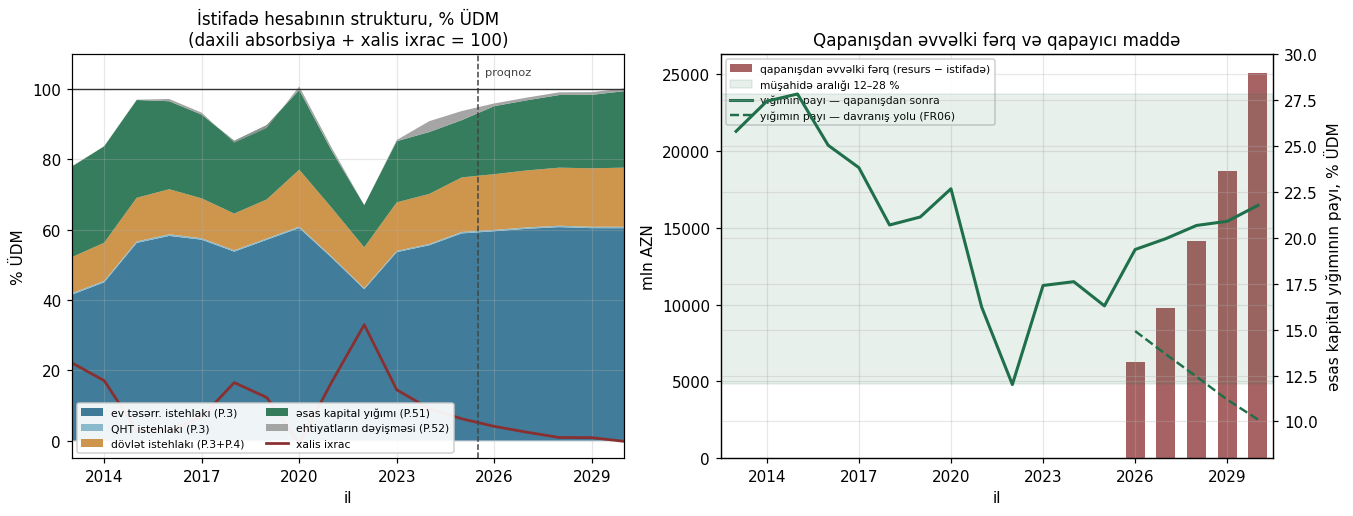

qrafik: outputs/figures/fr01b_resurslar_istifade.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
_yrs = [int(y) for y in ACC.index]
_ticks = [y for y in _yrs if y % 3 == 1]

ax = axes[0]
comp = ["ev təsərr. istehlakı (P.3)", "QHT istehlakı (P.3)", "dövlət istehlakı (P.3+P.4)",
        "əsas kapital yığımı (P.51)", "ehtiyatların dəyişməsi (P.52)"]
cols = ["#2c6e8f", "#7fb3c8", "#c98b3a", "#1f6f4a", "#9b9b9b"]
ax.stackplot(_yrs, *[ACC[c] / ACC["ÜDM"] * 100 for c in comp], labels=comp, colors=cols, alpha=0.9)
ax.plot(_yrs, (ACC["ixrac (P.6)"] - ACC["idxal (P.7)"]) / ACC["ÜDM"] * 100, lw=1.8,
        color="#8a2f2f", label="xalis ixrac")
ax.axvline(LA + 0.5, color="#444444", lw=1.0, ls="--")
ax.axhline(100, color="#333333", lw=0.9)
ax.set_title("İstifadə hesabının strukturu, % ÜDM\n(daxili absorbsiya + xalis ixrac = 100)")
ax.set_xlabel("il"); ax.set_ylabel("% ÜDM")
ax.set_xticks(_ticks); ax.set_xlim(_yrs[0], _yrs[-1]); ax.set_ylim(-5, 110)
ax.legend(fontsize=7, loc="lower left", ncol=2, framealpha=0.92)
ax.text(LA + 0.7, 104, "proqnoz", fontsize=7.5, color="#444444")

ax = axes[1]
_lo_i2 = float(SHARE_HIST["əsas kapital yığımı"].min() * 100)
_hi_i2 = float(SHARE_HIST["əsas kapital yığımı"].max() * 100)
ax.bar(list(FY), GAP.values, color="#8a2f2f", alpha=0.75, width=0.62,
       label="qapanışdan əvvəlki fərq (resurs − istifadə)")
ax.set_ylabel("mln AZN"); ax.set_xlabel("il")
ax.set_xticks(_ticks); ax.set_xlim(_yrs[0] - 0.5, _yrs[-1] + 0.5)
ax2 = ax.twinx()
ax2.axhspan(_lo_i2, _hi_i2, color="#1f6f4a", alpha=0.10, zorder=0,
            label=f"müşahidə aralığı {_lo_i2:.0f}–{_hi_i2:.0f} %")
ax2.plot(_yrs, ACC["əsas kapital yığımı (P.51)"] / ACC["ÜDM"] * 100, lw=2.0, color="#1f6f4a",
         label="yığımın payı — qapanışdan sonra")
ax2.plot(list(FY), (I_BEH / Y_F * 100).values, lw=1.6, ls="--", color="#1f6f4a",
         label="yığımın payı — davranış yolu (FR06)")
ax2.set_ylabel("əsas kapital yığımının payı, % ÜDM")
ax2.set_ylim(8, 30)
ax.set_title("Qapanışdan əvvəlki fərq və qapayıcı maddə")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left", framealpha=0.92)
plt.tight_layout()
_fig = os.path.join(config.FIG, "fr01b_resurslar_istifade.png")
plt.savefig(_fig, dpi=140, bbox_inches="tight")
plt.show()
print(f"qrafik: {os.path.relpath(_fig, config.BASE)}")

## 6. FR01-in tələb nüvəsi ilə çarpaz yoxlama

Paketdə indi tələb tərəfinin **iki müstəqil ölçüsü** var və onların uzlaşması bu dəftərin ən
güclü sınağıdır.

* **FR01, Bölmə 7.6** — qeyri-neft ÜDM-in tələb nüvəsi (investisiya, son istehlak, tərəfdaş
  artımı və rejim süni dəyişənləri ilə həll olunan simultan blok) istehsal oxunuşundan nə qədər
  aşağı qalır: `gdp_nonoil_gap`.
* **Bu dəftər** — bütün istifadə hesabının resurslardan nə qədər aşağı qalması: `use_balance_gap`.

İki kəmiyyət **fərqli yollarla** qurulur: birincisi bir davranış tənliyinin qalığıdır, ikincisi
altı komponentli mühasibat hesabının qalığı. Onların üst-üstə düşməsi məcburi deyil — üst-üstə
düşürlərsə, hər ikisi eyni real hadisəni ölçür.

In [12]:
NONOIL_GAP = col("FR2", "gdp_nonoil_gap").reindex(FY)
cross = pd.DataFrame({
    "resurslar–istifadə fərqi (FR1b), mln AZN": GAP,
    "tələb nüvəsinin fərqi (FR2 `gdp_nonoil_gap`), mln AZN": NONOIL_GAP,
    "fərqlərin fərqi, mln AZN": GAP - NONOIL_GAP,
    "nisbət": GAP / NONOIL_GAP,
    # HƏR İKİSİ EYNİ VAHİDDƏ: məcmu ÜDM-in faizi. FR01 həmin sütunu öz 7.6 bölməsində çap edir
    # (`fərq, % məcmu ÜDM`), ona görə iki dəftərin rəqəmləri çevirmə olmadan tutuşdurula bilir.
    "FR1b, % ÜDM": GAP_PCT,
    "tələb nüvəsi, % ÜDM": NONOIL_GAP / Y_F * 100,
})
print("İKİ MÜSTƏQİL FƏRQ ÖLÇÜSÜ:")
display(cross.round(2))
print(f"\nÜfüqün sonunda iki ölçü praktik olaraq eyniləşir: 2029-cu ildə nisbət "
      f"{float(cross['nisbət'].loc[2029]):.3f}, 2030-cu ildə {float(cross['nisbət'].loc[2030]):.3f} "
      f"(fərqlərin fərqi {float(cross['fərqlərin fərqi, mln AZN'].loc[2030]):,.0f} mln AZN, "
      f"ÜDM-in {float(cross['fərqlərin fərqi, mln AZN'].loc[2030] / Y_F.loc[2030] * 100):.2f} %-i).")
print("İlk illərdə fərq daha böyükdür, çünki tələb nüvəsi YALNIZ qeyri-neft blokunu ölçür, "
      "istifadə\nhesabı isə bütün iqtisadiyyatı; neft-qaz bloku isə erkən illərdə ixracın "
      "yolu ilə hesabın\nresurs tərəfinə daha çox töhfə verir.")
print(f"Məcmu ÜDM-in faizi ilə: bu dəftər {float(GAP_PCT.loc[2026]):.2f} % → "
      f"{float(GAP_PCT.loc[2030]):.2f} %, tələb nüvəsi "
      f"{float((NONOIL_GAP / Y_F * 100).loc[2026]):.2f} % → "
      f"{float((NONOIL_GAP / Y_F * 100).loc[2030]):.2f} % — FR01-in 7.6 bölməsində çap olunan "
      f"«fərq, % məcmu ÜDM»\nsütunu ilə eyni kəmiyyətdir və oradakı rəqəmlərlə üst-üstə düşməlidir.")

İKİ MÜSTƏQİL FƏRQ ÖLÇÜSÜ:


,"resurslar–istifadə fərqi (FR1b), mln AZN","tələb nüvəsinin fərqi (FR2 `gdp_nonoil_gap`), mln AZN","fərqlərin fərqi, mln AZN",nisbət,"FR1b, % ÜDM","tələb nüvəsi, % ÜDM"
year,,,,,,
2026,6282.27,3015.89,3266.38,2.08,4.44,2.13
2027,9795.05,7231.93,2563.12,1.35,6.29,4.65
2028,14165.96,12178.74,1987.22,1.16,8.23,7.08
2029,18722.61,18233.47,489.14,1.03,9.71,9.46
2030,25049.71,25531.91,-482.20,0.98,11.66,11.88



Üfüqün sonunda iki ölçü praktik olaraq eyniləşir: 2029-cu ildə nisbət 1.027, 2030-cu ildə 0.981 (fərqlərin fərqi -482 mln AZN, ÜDM-in -0.22 %-i).
İlk illərdə fərq daha böyükdür, çünki tələb nüvəsi YALNIZ qeyri-neft blokunu ölçür, istifadə
hesabı isə bütün iqtisadiyyatı; neft-qaz bloku isə erkən illərdə ixracın yolu ilə hesabın
resurs tərəfinə daha çox töhfə verir.
Məcmu ÜDM-in faizi ilə: bu dəftər 4.44 % → 11.66 %, tələb nüvəsi 2.13 % → 11.88 % — FR01-in 7.6 bölməsində çap olunan «fərq, % məcmu ÜDM»
sütunu ilə eyni kəmiyyətdir və oradakı rəqəmlərlə üst-üstə düşməlidir.


## 7. Nəticələrin ixracı

Dəftər `assumptions.csv` faylına **yazmır** — o, heç bir yuxarı axın fərziyyəsini yaratmır və
aşağı axının heç bir dəftəri onun çıxışını giriş kimi oxumur. Yazdığı üç fayl var:
`forecast_long.csv` (`fr = FR1B`), `series_dictionary.csv` və `equations_catalog.csv`.
`validation_backtest.csv`-yə də yazmır: dəftərdə qiymətləndirilmiş tənlik yoxdur, ona görə
geriyə doğru sınaq obyekti də yoxdur (eyni səbəblə FR03 yalnız bant etalonu yazır).

In [13]:
# --- 1. UZUN FORMATLI PROQNOZ -----------------------------------------------------------------
CONS_TOT = (ACC["ev təsərr. istehlakı (P.3)"] + ACC["QHT istehlakı (P.3)"]
            + ACC["dövlət istehlakı (P.3+P.4)"])
GCF = ACC["əsas kapital yığımı (P.51)"] + ACC["ehtiyatların dəyişməsi (P.52)"]
ABSORP = CONS_TOT + GCF
NX = ACC["ixrac (P.6)"] - ACC["idxal (P.7)"]
I_BEH_ALL = pd.concat([(INV_FR6 * PHI).loc[HW], I_BEH]).sort_index()
BAL_GAP = pd.concat([U["stat_discrepancy"].loc[HW], GAP]).sort_index()

SER = {
    "use_hh_cons": ("Ev təsərrüfatlarının son istehlak xərcləri (P.3)",
                    "Household final consumption expenditure (P.3)", "mln AZN",
                    ACC["ev təsərr. istehlakı (P.3)"], "cari"),
    "use_npish_cons": ("QHT-lərin son istehlak xərcləri (P.3)",
                       "NPISH final consumption expenditure (P.3)", "mln AZN",
                       ACC["QHT istehlakı (P.3)"], "cari"),
    "use_gov_cons": ("Dövlətin son istehlak xərcləri (P.3+P.4)",
                     "Government final consumption expenditure (P.3+P.4)", "mln AZN",
                     ACC["dövlət istehlakı (P.3+P.4)"], "cari"),
    "use_cons_total": ("Son istehlak xərcləri, cəmi", "Final consumption expenditure, total",
                       "mln AZN", CONS_TOT, "cari"),
    "use_gfcf": ("Əsas kapitalın ümumi yığımı (P.51) — balanslaşdırılmış",
                 "Gross fixed capital formation (P.51), balanced", "mln AZN",
                 ACC["əsas kapital yığımı (P.51)"], "cari"),
    "use_inventories": ("Ehtiyatların dəyişməsi (P.52)", "Changes in inventories (P.52)",
                        "mln AZN", ACC["ehtiyatların dəyişməsi (P.52)"], "cari"),
    "use_gcf": ("Ümumi yığım (P.5)", "Gross capital formation (P.5)", "mln AZN", GCF, "cari"),
    "use_exports": ("Mal və xidmətlərin ixracı (P.6)", "Exports of goods and services (P.6)",
                    "mln AZN", ACC["ixrac (P.6)"], "cari"),
    "use_imports": ("Mal və xidmətlərin idxalı (P.7)", "Imports of goods and services (P.7)",
                    "mln AZN", ACC["idxal (P.7)"], "cari"),
    "use_net_exports": ("Mal və xidmətlərin xalis ixracı (P.6n)",
                        "Net exports of goods and services (P.6n)", "mln AZN", NX, "cari"),
    "use_absorption": ("Daxili absorbsiya (son istehlak + ümumi yığım)",
                       "Domestic absorption (final consumption + gross capital formation)",
                       "mln AZN", ABSORP, "cari"),
    "use_resources": ("Məcmu resurslar (ÜDM + idxal)", "Total resources (GDP + imports)",
                      "mln AZN", ACC["MƏCMU RESURSLAR"], "cari"),
    "use_uses": ("Məcmu istifadə (son istehlak + yığım + ixrac)",
                 "Total uses (final consumption + capital formation + exports)", "mln AZN",
                 ACC["MƏCMU İSTİFADƏ"], "cari"),
    "use_gdp": ("ÜDM — istifadə (xərc) metodu ilə", "GDP by expenditure (use account)",
                "mln AZN", ACC["ÜDM"], "cari"),
    "use_gfcf_behavioural": ("Əsas kapital yığımının davranış oxunuşu (FR06 yolundan)",
                             "Gross fixed capital formation, behavioural reading (from FR06)",
                             "mln AZN", I_BEH_ALL, "cari"),
    "use_balance_gap": ("Resurslar–istifadə fərqi (balanslaşdırmadan əvvəl)",
                        "Resources-uses gap before balancing", "mln AZN", BAL_GAP, "cari"),
    "use_stat_discrepancy": ("Statistik fərq (istifadə hesabı)",
                             "Statistical discrepancy (use account)", "mln AZN",
                             ACC["statistik fərq"], "cari"),
}
SER_FC_ONLY = {
    "use_balance_gap_pct": ("Resurslar–istifadə fərqi, % ÜDM", "Resources-uses gap, % of GDP",
                            "%", GAP_PCT, "indeks"),
    "use_gfcf_gap": ("Qapanışın qiyməti: yığımın davranış yolundan fərqi",
                     "Cost of closure: capital formation deviation from behavioural path",
                     "mln AZN", GFCF_GAP, "cari"),
    "use_gfcf_gap_pct": ("Qapanışın qiyməti, davranış yolunun %-i",
                         "Cost of closure, % of behavioural path", "%", GFCF_GAP_PCT, "indeks"),
    "use_imports_clearing": ("Bazarı təmizləyən idxal (rədd edilmiş qapanış)",
                             "Market-clearing imports (rejected closure)", "mln AZN",
                             M_CLEAR, "cari"),
    "use_absorption_lambda": ("Mütənasib absorbsiya əmsalı λ (rədd edilmiş qapanış)",
                              "Proportional absorption factor (rejected closure)", "əmsal",
                              LAMBDA, "indeks"),
}
SHARE_SER = {
    "use_share_hh_cons": ("Ev təsərrüfatı istehlakının ÜDM-də payı",
                          "Household consumption, share of GDP", "ev təsərr. istehlakı (P.3)"),
    "use_share_gov_cons": ("Dövlət istehlakının ÜDM-də payı", "Government consumption, share of GDP",
                           "dövlət istehlakı (P.3+P.4)"),
    "use_share_gfcf": ("Əsas kapital yığımının ÜDM-də payı",
                       "Gross fixed capital formation, share of GDP", "əsas kapital yığımı (P.51)"),
    "use_share_inventories": ("Ehtiyatların dəyişməsinin ÜDM-də payı",
                              "Changes in inventories, share of GDP",
                              "ehtiyatların dəyişməsi (P.52)"),
    "use_share_exports": ("İxracın ÜDM-də payı", "Exports, share of GDP", "ixrac (P.6)"),
    "use_share_imports": ("İdxalın ÜDM-də payı", "Imports, share of GDP", "idxal (P.7)"),
}

rows_f = []


def _emit(code_, nm, unit, ser):
    for y, val in pd.Series(ser).dropna().items():
        y = int(y)
        if y < 2013 or y > config.LAST_FORECAST:
            continue
        rows_f.append({"fr": FR, "series_code": code_, "series_name_az": nm, "unit": unit,
                       "year": y, "kind": "actual" if y <= LA else "forecast", "source": "ours",
                       "value": round(float(val), 4), "lo80": None, "hi80": None,
                       "lo50": None, "hi50": None})


for c, (nm, _en, unit, ser, _pb) in SER.items():
    _emit(c, nm, unit, ser)
for c, (nm, _en, unit, ser, _pb) in SER_FC_ONLY.items():
    _emit(c, nm, unit, ser)
for c, (nm, _en, key) in SHARE_SER.items():
    _emit(c, nm, "%", ACC[key] / ACC["ÜDM"] * 100)
_emit("use_share_absorption", "Daxili absorbsiyanın ÜDM-də payı", "%", ABSORP / ACC["ÜDM"] * 100)

fl = outputs.write_forecast_long(pd.DataFrame(rows_f))
print(f"forecast_long.csv: {FR} üzrə {len(rows_f)} sətir yazıldı "
      f"({pd.DataFrame(rows_f)['series_code'].nunique()} sıra kodu); faylda cəmi {len(fl)} sətir")

forecast_long.csv: FR1B üzrə 457 sətir yazıldı (29 sıra kodu); faylda cəmi 14603 sətir


In [14]:
# --- 2. SIRA LÜĞƏTİ ---------------------------------------------------------------------------
REF = "DSK 27 (027en) «Gross domestic product use»; MİİS §15.5.1 icmal qeydi — tələb-təklif tarazlığı"
NOTE_BAL = ("QAPAYICI (balanslaşdırıcı) MADDƏ: proqnoz illərində bu sıra resurslar–istifadə "
            "eyniliyinin qalığını daşıyır (qapanma qaydası — FR01b, Bölmə 4). Davranış "
            "oxunuşu ayrıca sıradadır (`use_gfcf_behavioural`), fərq isə `use_gfcf_gap`.")
NOTE_GAP = ("FAKTİKİ illərdə DSK-nın ÖZ statistik fərqidir (27-ci cədvəl, sətir 19); PROQNOZ "
            "illərində paketin davranış bloklarından gələn resurs–istifadə fərqidir, yəni "
            "balanslaşdırmadan ƏVVƏLKİ qalıq.")
NOTE_REJ = ("RƏDD EDİLMİŞ QAPANIŞ — nəşr olunan mərkəzi yol DEYİL; yalnız qapanma qaydasının "
            "nəticəyə təsirinin ölçülməsi üçün saxlanılır (FR01b, Bölmə 4.1).")
_extra = {"use_gfcf": NOTE_BAL, "use_balance_gap": NOTE_GAP, "use_balance_gap_pct": NOTE_GAP,
          "use_stat_discrepancy": ("FAKTİKİ illərdə DSK 27-nin öz sətri (19); PROQNOZ illərində "
                                   "SIFIR — qapanış qalığı statistik fərqə deyil, qapayıcı "
                                   "maddəyə verilir (FR01b, Bölmə 4)."),
          "use_imports_clearing": NOTE_REJ, "use_absorption_lambda": NOTE_REJ,
          "use_gfcf_behavioural": ("FR06-nın `inv_total_nom` yolundan φ körpüsü ilə törədilmiş "
                                   "yığım; MÜŞAHİDƏ DEYİL, qurulmuş kəmiyyətdir.")}
dict_rows = []
for c, (nm, en, unit, _s, pb) in {**SER, **SER_FC_ONLY}.items():
    dict_rows.append({"series_code": c, "name_az": nm, "name_en": en, "unit": unit, "fr": FR,
                      "statutory_sheet_ref": REF + ("; " + _extra[c] if c in _extra else ""),
                      "price_basis": pb})
for c, (nm, en, _k) in SHARE_SER.items():
    dict_rows.append({"series_code": c, "name_az": nm, "name_en": en, "unit": "%", "fr": FR,
                      "statutory_sheet_ref": REF, "price_basis": "indeks"})
dict_rows.append({"series_code": "use_share_absorption",
                  "name_az": "Daxili absorbsiyanın ÜDM-də payı",
                  "name_en": "Domestic absorption, share of GDP", "unit": "%", "fr": FR,
                  "statutory_sheet_ref": REF, "price_basis": "indeks"})
sd = outputs.write_series_dictionary(pd.DataFrame(dict_rows))
print(f"series_dictionary.csv: {len(dict_rows)} sıra qeydiyyata alındı; faylda cəmi {len(sd)} sətir")

series_dictionary.csv: 29 sıra qeydiyyata alındı; faylda cəmi 681 sətir


In [15]:
# --- 3. TƏNLİKLƏR KATALOQU --------------------------------------------------------------------
cat_rows = [
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_resurslar_istifade_eynilikleri",
     "description": ("EYNİLİK (baş): ÜDM + idxal = ev təsərrüfatı, QHT və dövlətin son istehlakı "
                     "+ əsas kapital yığımı + ehtiyatların dəyişməsi + ixrac + statistik fərq. "
                     f"2013–{config.LAST_FORECAST} illərinin HAMISI üçün bağlanır; maksimal "
                     f"qalıq {float(ACC['QALIQ'].abs().max()):.2e} mln AZN"),
     "lhs": "use_resources", "rhs": "use_cons_total + use_gcf + use_exports",
     "series_code": "use_resources", "fr": FR, "sample_start": 2013,
     "sample_end": config.LAST_FORECAST, "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_qapanma_qaydasi",
     "description": ("QAPANMA QAYDASI: qalıq, implisit payı 2013–2025 müşahidə aralığında qalan "
                     f"YEGANƏ namizədə verilir. Test altı namizəd və mütənasib λ variantı üzrə "
                     f"aparılır; keçən namizəd — «{CLOSER}» (payı {float(SHR.loc[FY, 'əsas kapital yığımı (P.51)'].min()):.1f}–"
                     f"{float(SHR.loc[FY, 'əsas kapital yığımı (P.51)'].max()):.1f} %, aralıq "
                     f"[{float(SHARE_HIST['əsas kapital yığımı'].min() * 100):.1f}; "
                     f"{float(SHARE_HIST['əsas kapital yığımı'].max() * 100):.1f}])"),
     "lhs": "use_gfcf", "rhs": "use_gfcf_behavioural + use_balance_gap",
     "series_code": "use_gfcf", "fr": FR, "sample_start": 2013, "sample_end": LA,
     "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_ev_teserrufati_istehlaki_korpusu",
     "description": ("KÖRPÜ: C(t) = C(t−1)·(1+g_cons_core)·(1+cpi_infl). Baza səviyyə DSK 27-nin "
                     "P.3 sətridir və iş kitabının `final_consumption` sırası ilə EYNİDİR "
                     f"(maksimal fərq {float((data_layer.actuals('final_consumption') - U['hh_cons_final']).abs().max()):.3f} "
                     "mln AZN), ona görə FR01 nüvəsinin real artım yolu birbaşa tətbiq olunur. "
                     "Deflyator kimi İQİ götürülür — AÇIQ KONVENSİYA, ölçü deyil"),
     "lhs": "use_hh_cons", "rhs": "g_cons_core, cpi_infl", "series_code": "use_hh_cons",
     "fr": FR, "sample_start": LA, "sample_end": config.LAST_FORECAST,
     "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_yigim_investisiya_korpusu",
     "description": (f"KALİBRLƏMƏ: φ = P.51 ÷ `inv_total_nom`, son {PHI_WIN} ilin ortası = "
                     f"{PHI:.4f}. İki sıra fərqli statistik anlayışdır; nisbət 2013–{LA} "
                     f"aralığında {float((U['gfcf_total'] / INV_FR6).loc[HW].min()):.3f}–"
                     f"{float((U['gfcf_total'] / INV_FR6).loc[HW].max()):.3f} arasında dəyişir"),
     "lhs": "use_gfcf_behavioural", "rhs": "inv_total_nom × φ",
     "series_code": "use_gfcf_behavioural", "fr": FR, "sample_start": LA - PHI_WIN + 1,
     "sample_end": LA, "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_ehtiyatlar_normasi",
     "description": (f"KALİBRLƏMƏ: ΔS = ν·ÜDM, ν = son {NU_WIN} ilin orta payı = {NU * 100:.3f} % "
                     f"ÜDM. Sıra işarəsini müşahidə pəncərəsində altı dəfə dəyişdiyi üçün davranış "
                     f"tənliyi qiymətləndirilmir; norma TƏSBİT olunur və qapayıcı maddə DEYİL"),
     "lhs": "use_inventories", "rhs": "ÜDM × ν", "series_code": "use_inventories", "fr": FR,
     "sample_start": LA - NU_WIN + 1, "sample_end": LA, "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_qht_istehlaki",
     "description": (f"KALİBRLƏMƏ: C_QHT = κ·C_ev, κ = son {KAPPA_WIN} ilin orta nisbəti = "
                     f"{KAPPA * 100:.3f} %; sıranın ÜDM-dəki payı {float((U['npish_cons_final'] / U['gdp_use']).loc[HW].max() * 100):.2f} "
                     "%-i keçmir"),
     "lhs": "use_npish_cons", "rhs": "use_hh_cons × κ", "series_code": "use_npish_cons",
     "fr": FR, "sample_start": LA - KAPPA_WIN + 1, "sample_end": LA,
     "adj_r2": None, "se_regression": None},
    {"workbook": WB, "sheet": SH, "eq_name": "FR1b_ticaret_korpusu",
     "description": ("EYNİLİK: ixrac və idxalın manatla yolu = FR07-nin dollarla axınları × "
                     "FR10-un orta illik məzənnəsi. Körpü faktiki illərdə DSK 27-nin öz "
                     f"sətirləri ilə tutuşdurulur: maksimal fərq "
                     f"{float(pd.concat([(U['exports_gs'] - X_PKG).loc[HW].abs(), (U['imports_gs'] - M_PKG).loc[HW].abs()]).max()):.2f} "
                     "mln AZN"),
     "lhs": "use_exports, use_imports", "rhs": "(exp_goods + exp_services) × fx_usd_azn_avg; "
                                               "(imp_goods + imp_services) × fx_usd_azn_avg",
     "series_code": "use_exports", "fr": FR, "sample_start": 2013,
     "sample_end": config.LAST_FORECAST, "adj_r2": None, "se_regression": None},
]
ec = outputs.write_equations_catalog(pd.DataFrame(cat_rows))
display(ec[ec["fr"] == FR][["eq_name", "lhs", "rhs", "sample_start", "sample_end"]])

,eq_name,lhs,rhs,sample_start,sample_end
162,FR1b_ehtiyatlar_normasi,use_inventories,ÜDM × ν,2016,2025
163,FR1b_ev_teserrufati_istehlaki_korpusu,use_hh_cons,"g_cons_core, cpi_infl",2025,2030
164,FR1b_qapanma_qaydasi,use_gfcf,use_gfcf_behavioural + use_balance_gap,2013,2025
165,FR1b_qht_istehlaki,use_npish_cons,use_hh_cons × κ,2021,2025
166,FR1b_resurslar_istifade_eynilikleri,use_resources,use_cons_total + use_gcf + use_exports,2013,2030
167,FR1b_ticaret_korpusu,"use_exports, use_imports",(exp_goods + exp_services) × fx_usd_azn_avg; (...,2013,2030
168,FR1b_yigim_investisiya_korpusu,use_gfcf_behavioural,inv_total_nom × φ,2023,2025


### 7.1. Yoxlama

Yoxlama harness-i (`validate.Verifier`) dəftərin bütün eyniliklərini, körpülərini və nəşr olunan
sətirləri **diskdən geri oxuyaraq** sınayır. Baş yoxlama sonuncudur: resurslar–istifadə
eyniliyinin `outputs/forecast_long.csv` faylının ÖZ sətirləri üzərində, hər il üçün bağlanması.

In [16]:
v = validate.Verifier("FR01b — resurslar–istifadə balansı və tələb-təklif tarazlığı")

# 1. Mənbənin öz eynilikləri (məlumat qatından MÜSTƏQİL yenidən hesablanır)
v.identity("DSK 27: ÜDM = son istehlak + ümumi yığım + xalis ixrac + statistik fərq",
           U["gdp_use"].dropna(),
           (U["cons_final_total"] + U["gcf_total"] + U["exports_gs"] - U["imports_gs"]
            + U["stat_discrepancy"]).dropna(), tol=0.15)
v.identity("DSK 27: P.5 = P.51 + P.52", U["gcf_total"].dropna(),
           (U["gfcf_total"] + U["inventories_chg"]).dropna(), tol=1e-9)
v.identity("DSK 27: P.6n = P.6 − P.7", U["net_exports_gs"].dropna(),
           (U["exports_gs"] - U["imports_gs"]).dropna(), tol=0.15)

# 2. İki istehlak bazası eyni cəmi verir (ikiqat saymaya qarşı struktur yoxlama)
v.identity("istehlak: P.4 bazası = cəmi", (U["hh_cons_actual"] + U["gov_cons_collect"]).dropna(),
           U["cons_final_total"].dropna(), tol=0.11)
v.identity("istehlak: P.3 bazası = cəmi",
           (U["hh_cons_final"] + U["npish_cons_final"] + U["gov_cons_total"]).dropna(),
           U["cons_final_total"].dropna(), tol=0.11)

# 3. Körpülər
v.identity(f"körpü: iş kitabının `final_consumption` = DSK 27 P.3 (2013–{LA})",
           data_layer.actuals("final_consumption").reindex(HW), U["hh_cons_final"].reindex(HW),
           tol=0.11)
v.identity("körpü: ixrac (FR07 × FR10) = DSK 27 P.6 (faktiki illər)",
           X_PKG.reindex(HW), U["exports_gs"].reindex(HW), tol=2.0)
v.identity("körpü: idxal (FR07 × FR10) = DSK 27 P.7 (faktiki illər)",
           M_PKG.reindex(HW), U["imports_gs"].reindex(HW), tol=2.0)
_gy = [y for y in HW if y != 2024]
v.identity("ÜDM: istehsal hesabı = istifadə hesabı (2024 buraxılış fərqi istisna)",
           GDP_PROD.reindex(_gy), U["gdp_use"].reindex(_gy), tol=0.5)
v.ok("2024-cü ilin fərqi məlum BURAXILIŞ fərqidir və 200 mln AZN-i keçmir",
     bool(abs(float(U.loc[2024, "gdp_use"] - GDP_PROD.loc[2024])) < 200.0),
     f"fərq {float(U.loc[2024, 'gdp_use'] - GDP_PROD.loc[2024]):.2f} mln AZN")

# 4. BAŞ YOXLAMA — balans hər il üçün bağlanır. Faktiki illərdə dözüm mənbənin öz
#    yuvarlaqlaşmasıdır (DSK 27 bir onluq işarə ilə nəşr olunur), proqnoz illərində isə
#    qapanış konstruksiya ilə dəqiq olduğu üçün dözüm maşın dəqiqliyindədir.
v.identity(f"BALANS: resurslar = istifadə (faktiki illər 2013–{LA})",
           ACC["MƏCMU RESURSLAR"].reindex(HW), ACC["MƏCMU İSTİFADƏ"].reindex(HW), tol=0.11)
v.identity(f"BALANS: resurslar = istifadə (proqnoz 2026–{config.LAST_FORECAST}, HƏR il)",
           ACC["MƏCMU RESURSLAR"].reindex(FY), ACC["MƏCMU İSTİFADƏ"].reindex(FY), tol=1e-6)
v.identity("daxili absorbsiya + xalis ixrac + statistik fərq = ÜDM (hər il)",
           ABSORP + NX + ACC["statistik fərq"], ACC["ÜDM"], tol=0.11)
v.identity("ümumi yığım = əsas kapital + ehtiyatlar (hər il)", GCF,
           ACC["əsas kapital yığımı (P.51)"] + ACC["ehtiyatların dəyişməsi (P.52)"], tol=1e-9)
v.identity("qapanış: balanslaşdırılmış yığım = davranış yolu + fərq",
           I_BAL, I_BEH + GAP, tol=1e-9)

# 5. Qapanma qaydasının nəticəsi doğrulanır
_lo_i3 = float(SHARE_HIST["əsas kapital yığımı"].min() * 100)
_hi_i3 = float(SHARE_HIST["əsas kapital yığımı"].max() * 100)
_sh_bal = SHR.loc[FY, "əsas kapital yığımı (P.51)"]
v.ok("qapayıcı maddənin implisit payı müşahidə aralığındadır",
     bool(_sh_bal.min() >= _lo_i3 and _sh_bal.max() <= _hi_i3),
     f"proqnoz payı {float(_sh_bal.min()):.2f}–{float(_sh_bal.max()):.2f} %, "
     f"aralıq [{_lo_i3:.2f}; {_hi_i3:.2f}] %")
v.ok("qapanma testini yalnız bir namizəd keçir", bool(len(PASSED) == 1),
     f"keçən: {PASSED}")

# 6. Kalibrləmə pəncərələri proqnoz üfüqünə toxunmur
v.no_lookahead("φ kalibrləmə pəncərəsi", pd.Index(range(LA - PHI_WIN + 1, LA + 1)))
v.no_lookahead("ν kalibrləmə pəncərəsi", pd.Index(range(LA - NU_WIN + 1, LA + 1)))
v.no_lookahead("κ kalibrləmə pəncərəsi", pd.Index(range(LA - KAPPA_WIN + 1, LA + 1)))
v.no_lookahead("pay aralığı testinin pəncərəsi", pd.Index(HW))

# 7. Nəşr olunan sətirlər DİSKDƏN geri oxunur və eynilik ORADA da yoxlanılır
_fl = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
_b = _fl[(_fl["fr"] == FR) & (_fl["source"] == "ours")]


def _d(code_):
    return _b[_b["series_code"] == code_].set_index("year")["value"].sort_index().astype(float)


v.identity("forecast_long (diskdən): resurslar = ÜDM + idxal", _d("use_resources"),
           _d("use_gdp") + _d("use_imports"), tol=1e-3)
v.identity("forecast_long (diskdən): istifadə = son istehlak + yığım + ixrac + statistik fərq",
           _d("use_uses"),
           _d("use_cons_total") + _d("use_gcf") + _d("use_exports") + _d("use_stat_discrepancy"),
           tol=1e-3)
v.identity(f"forecast_long (diskdən): BALANS bağlanır (faktiki 2013–{LA})",
           _d("use_resources").reindex(HW), _d("use_uses").reindex(HW), tol=0.11)
v.identity(f"forecast_long (diskdən): BALANS bağlanır (proqnoz 2026–{config.LAST_FORECAST})",
           _d("use_resources").reindex(FY), _d("use_uses").reindex(FY), tol=1e-3)
v.identity("forecast_long (diskdən): son istehlak = üç komponentin cəmi", _d("use_cons_total"),
           _d("use_hh_cons") + _d("use_npish_cons") + _d("use_gov_cons"), tol=1e-3)
v.ok("nəşr olunan bütün sıralar lüğətdə qeydiyyatdadır",
     bool(set(_b["series_code"]) <= set(pd.read_csv(config.O_SERIES_DICT)["series_code"])))

# 8. Müstəqil yenidən hesablama: 2030-cu ilin balansı ilkin girişlərdən yenidən qurulur
def _yeniden_2030():
    y = 2030
    _res = float(GDP_PROD.loc[y]) + float(M_USD.loc[y]) * float(FXA.loc[y])
    _use = (float(C_HH.loc[y]) + float(C_NP.loc[y]) + float(C_GOV.loc[y])
            + float(I_BAL.loc[y]) + float(D_INV.loc[y])
            + float(X_USD.loc[y]) * float(FXA.loc[y]))
    return _res - _use


v.recompute("2030-cu il balansının qalığı (ilkin girişlərdən yenidən)", shipped=0.0,
            fn=_yeniden_2030, tol=1e-6)

v.assert_all()

  YOXLAMA: FR01b — resurslar–istifadə balansı və tələb-təklif tarazlığı
  [PASS] eynilik: DSK 27: ÜDM = son istehlak + ümumi yığım + xalis ixrac + statistik fərq
         33 il, maksimal fərq 1.000e-01
  [PASS] eynilik: DSK 27: P.5 = P.51 + P.52
         33 il, maksimal fərq 3.638e-12
  [PASS] eynilik: DSK 27: P.6n = P.6 − P.7
         33 il, maksimal fərq 2.000e-02
  [PASS] eynilik: istehlak: P.4 bazası = cəmi
         33 il, maksimal fərq 1.000e-01
  [PASS] eynilik: istehlak: P.3 bazası = cəmi
         33 il, maksimal fərq 1.000e-01
  [PASS] eynilik: körpü: iş kitabının `final_consumption` = DSK 27 P.3 (2013–2025)
         13 il, maksimal fərq 0.000e+00
  [PASS] eynilik: körpü: ixrac (FR07 × FR10) = DSK 27 P.6 (faktiki illər)
         13 il, maksimal fərq 1.635e+00
  [PASS] eynilik: körpü: idxal (FR07 × FR10) = DSK 27 P.7 (faktiki illər)
         13 il, maksimal fərq 1.563e+00
  [PASS] eynilik: ÜDM: istehsal hesabı = istifadə hesabı (2024 buraxılış fərqi istisna)
         12 il, maks

In [17]:
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
dict_disk = pd.read_csv(config.O_SERIES_DICT)
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
print(f"forecast_long.csv, {FR} sətirləri     : {int((fl_disk['fr'] == FR).sum())}")
print(f"series_dictionary.csv, {FR} sıraları  : {int((dict_disk['fr'] == FR).sum())}")
print(f"equations_catalog.csv, {FR} sətirləri : {int((eq_disk['fr'] == FR).sum())}")
print(f"assumptions.csv-ə yazı                : yoxdur (dəftər fərziyyə açarı yaratmır)")
print(f"validation_backtest.csv-ə yazı        : yoxdur (qiymətləndirilmiş tənlik yoxdur)")

forecast_long.csv, FR1B sətirləri     : 457
series_dictionary.csv, FR1B sıraları  : 29
equations_catalog.csv, FR1B sətirləri : 7
assumptions.csv-ə yazı                : yoxdur (dəftər fərziyyə açarı yaratmır)
validation_backtest.csv-ə yazı        : yoxdur (qiymətləndirilmiş tənlik yoxdur)


## 8. Məhdudiyyətlər

**Balans bağlanır, lakin qapanış bir SEÇİMDİR.** Eynilik 2013–2030-un hər ili üçün qapanır və
bu, mühasibat faktıdır. Qalığın hansı maddəyə verildiyi isə qaydanın nəticəsidir; qayda açıqdır,
testi çap olunur və rədd edilmiş variantların ədədləri saxlanılır, lakin başqa bir qayda başqa
nəticə verərdi. Konkret olaraq: qalıq əsas kapital yığımına verilir, ona görə **nəşr olunan
`use_gfcf` sırası FR06-nın investisiya yolundan fərqlənir** — 2026-cı ildə 29,8 %, 2030-cu ildə
115,3 % yuxarı. Fərq `use_gfcf_gap` sırası ilə nəşr olunur və gizlədilmir; FR06-nın öz
`inv_total_nom` sırasına isə TOXUNULMUR (paketin iki oxunuşu var, biri digərini əvəz etmir).

**Fərqin özü modelin uyğunsuzluğudur, ölçmə xətası deyil.** Resurslar 2030-cu ildə istifadəni
ÜDM-in 11,7 %-i qədər üstələyir. Bu, üç mümkün mənbədən gəlir və dəftər onları AYIRA BİLMİR:
(i) istehsal tərəfinin artım yolu yüksəkdir; (ii) FR06-nın investisiya yolu aşağıdır;
(iii) istehlak deflyatoru üçün İQİ konvensiyası nominal istehlakı aşağı çəkir. Bölmə 6-nın
çarpaz yoxlaması göstərir ki, fərq FR01-in tələb nüvəsinin fərqi ilə (`gdp_nonoil_gap`) üfüqün
sonunda praktik olaraq eyniləşir — yəni iki müstəqil ölçü eyni hadisəni görür, lakin nə biri,
nə də digəri hadisənin SƏBƏBİNİ təyin etmir. Səbəbin ayrılması FR06-nın investisiya tənliyinin
və qiymət kanalının növbəti buraxılışda yenidən baxılmasını tələb edir.

**İstehlak deflyatoru — açıq konvensiya.** Ev təsərrüfatlarının nominal istehlak yolu İQİ
inflyasiyası ilə qurulur. Milli hesabların istehlak deflyatoru İQİ ilə eyni deyil: faktiki
illərdə implisit deflyator (nominal artım ÷ real artım) İQİ-dən orta hesabla fərqlənir və bu
fərq nominal səviyyəyə birbaşa keçir. Paketdə ayrıca istehlak deflyatoru tənliyi yoxdur;
uydurulmur, konvensiya açıq elan olunur və həssaslığı Bölmə 3.1-də göstərilir.

**Ehtiyatların norması sabitdir.** ΔS = ν·ÜDM qaydası ehtiyatların dəyişməsini proqnoz üfüqündə
ÜDM-in sabit 0,77 %-inə bərabər tutur. Faktiki sıra 2013–2025-də −0,82 % ilə +3,09 % arasında
dəyişir və işarəsini altı dəfə dəyişir, yəni norma **orta haldır, proqnoz deyil**. Ehtiyatlar
qapayıcı maddə seçilsəydi, payı 2030-cu ildə 12,4 %-ə qalxardı — məhz bu səbəbdən o, qapanma
testini keçmir.

**ÜDM-in iki buraxılışı.** İstifadə hesabının ÜDM-i (DSK 27) ilə paketin `gdp_nom` sırası
2024-cü ildə 187,2 mln AZN fərqlənir (ÜDM-in 0,15 %-i): paketin sırası DSK-nın rəsmi 2025
nəticələr buraxılışına lövbərlənib, DSK 27 isə öz cədvəl buraxılışını daşıyır. Fərq balansın
faktiki hissəsində qalır — düzəldilmir — və nəşr olunan `use_gdp` sırası 2024 üçün DSK 27-nin
öz rəqəmidir. Proqnoz illərində belə fərq yoxdur, çünki orada təklif tərəfi birbaşa
`gdp_prod`-dan gəlir.

**Qiymət və həcm bölgüsü yoxdur.** Hesab yalnız CARİ qiymətlərdədir. İstifadə komponentlərinin
real (sabit qiymətli) yolu və deflyatorları qurulmur, çünki bunun üçün hər komponentin öz
deflyatoru lazımdır və paketdə yalnız ikisi (İQİ və investisiya deflyatoru) var. Ona görə
dəftər «real tələb–real təklif» tarazlığını deyil, **nominal resurslar–istifadə balansını**
təmin edir; bu, DSK-nın 27-ci cədvəlinin öz əhatəsi ilə eynidir.